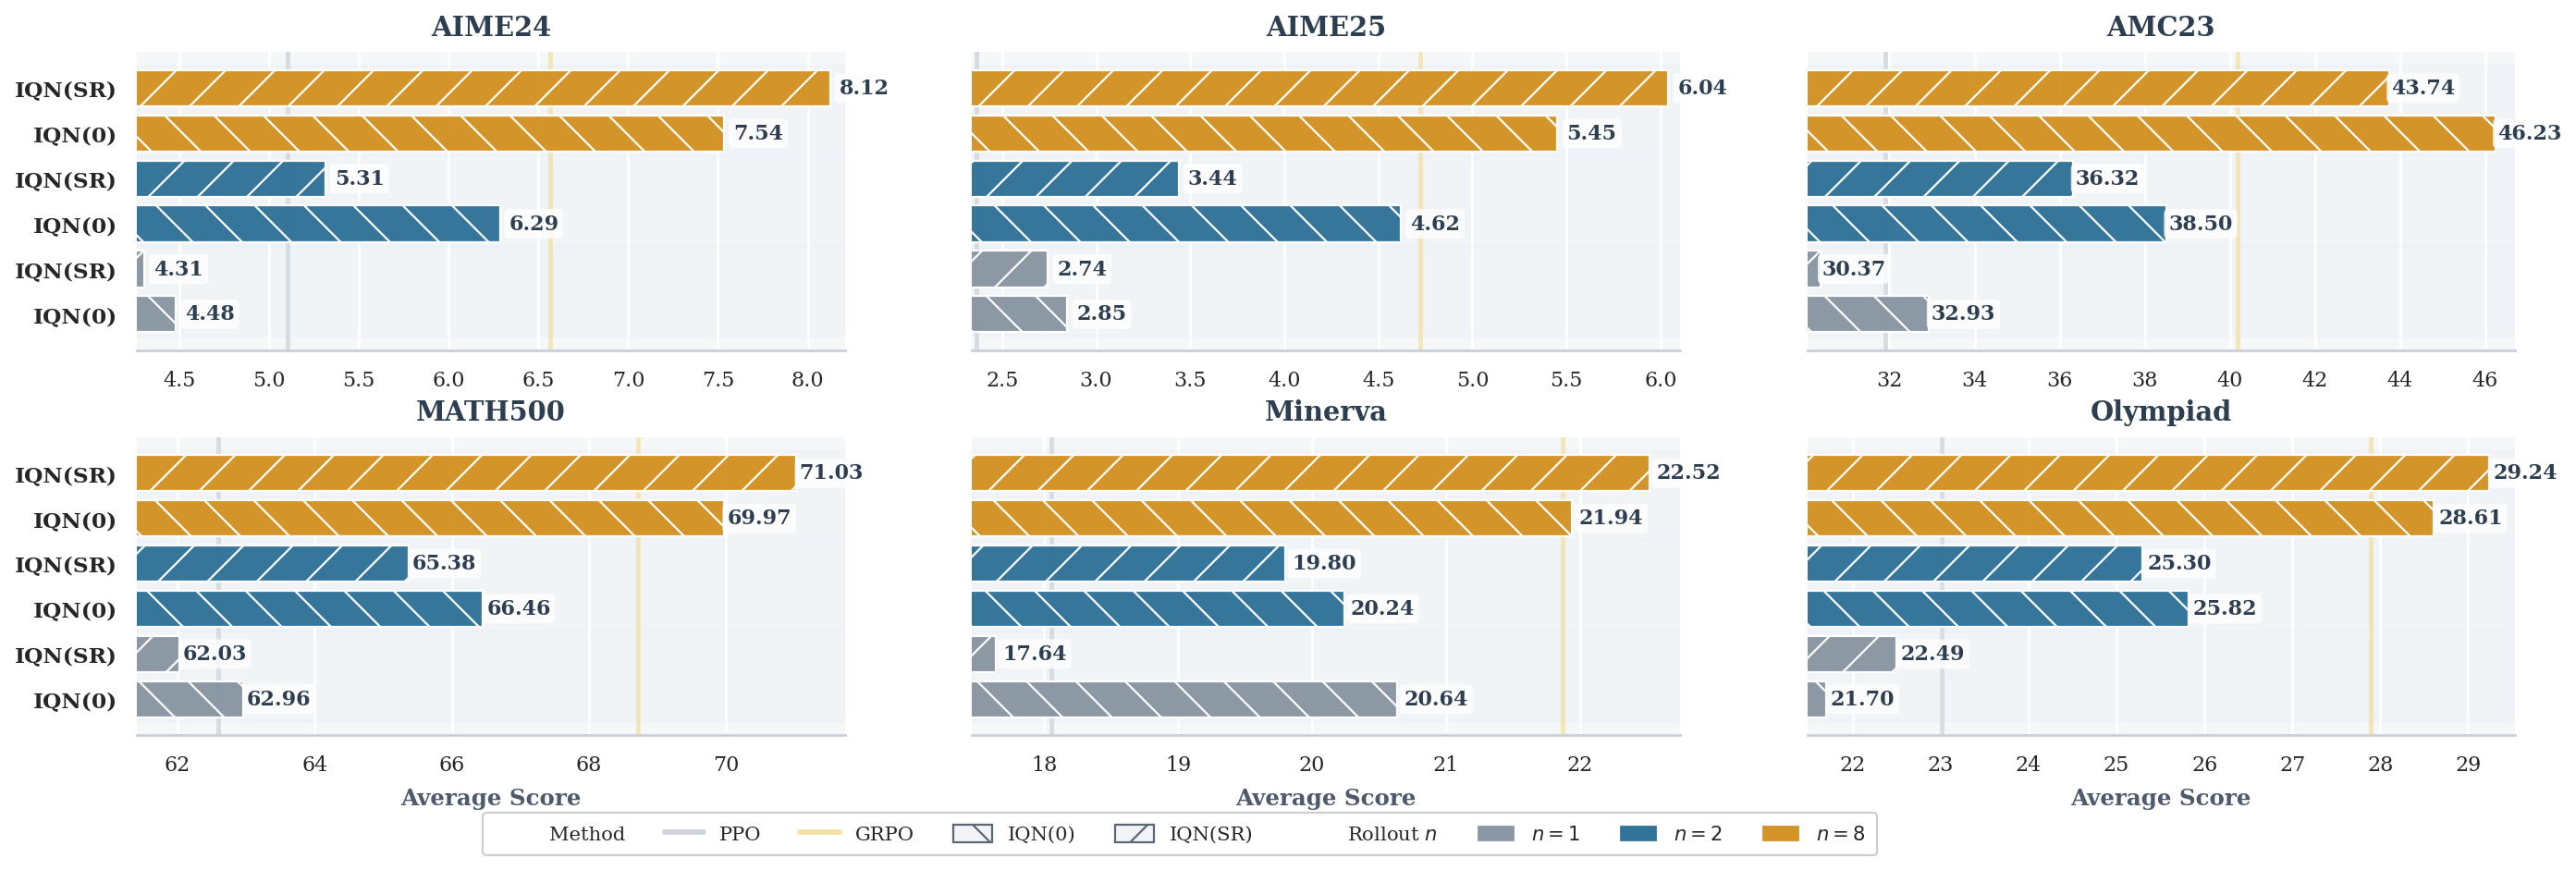

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

def plot_rolloutn_horizontal(
    df,
    *,
    title_main='AIME24',
    title_sub='',
    palette_name='slate_coral',
    show_group_panels=True,
    panel_color='#eef2f6',
    panel_alpha=0.6,
    ax=None,
    show_legend=True,
    tight_layout=True,
):
    """Horizontal bars: color by Rollout n, hatch by Method."""
    method_order = ['PPO', 'GRPO', 'IQN(0)', 'IQN(SR)']
    group_order = ['n=1', 'n=2', 'n=8']

    df = df.copy()
    df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)
    df['Group']  = pd.Categorical(df['Group'],  categories=group_order,  ordered=True)

    # ====== 风格 ======
    sns.set_theme(style='white', font_scale=1.2)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['axes.facecolor'] = '#f6f7f9'
    plt.rcParams['grid.color'] = 'white'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 1.2

    # ====== 配色：Rollout n ======
    palettes = {
        'slate_coral': {
            'n=1': '#C9D2DC',
            'n=2': '#88A2B8',
            'n=8': '#4C6E8A',
        },
        'navy_teal': {
            'n=1': '#8A96A3',
            'n=2': "#327399",
            'n=8': "#D39326",
        },
        'graphite_cyan': {
            'n=1': '#D5DBE0',
            'n=2': '#8CA3B3',
            'n=8': '#2F6F8F',
        },
    }
    palette = palettes.get(palette_name, palettes['slate_coral'])

    # ====== hatch：Method 固定 / \ . ======
    hatch_by_method = {
        'PPO': '',
        'GRPO': '',
        'IQN(0)': '\\',
        'IQN(SR)': '/',
    }

    # PPO/GRPO show as vertical lines
    special_methods = {
        'PPO': '#cfd4da',
        'GRPO': '#f2e1a3',
    }

    # ====== 数据排序 & 画图 ======
    df_lines = df[df['Method'].isin(special_methods.keys())].sort_values(['Group', 'Method']).copy()
    plot_df = df[~df['Method'].isin(special_methods.keys())].sort_values(['Group', 'Method']).copy()
    ypos = np.arange(len(plot_df))

    if ax is None:
        fig, ax = plt.subplots(figsize=(10.6, 5.6), dpi=160)
    else:
        fig = ax.figure

    ax.set_axisbelow(True)
    ax.xaxis.grid(True)

    # 记录每个 group 的 y 范围，用于 panel
    group_spans = {}
    for g in group_order:
        idx = np.where(plot_df['Group'].values == g)[0]
        if len(idx) == 0:
            continue
        group_spans[g] = (int(idx.min()), int(idx.max()))

    if show_group_panels:
        for i, (g, (ys, ye)) in enumerate(group_spans.items()):
            ax.axhspan(
                ys - 0.5, ye + 0.5,
                color=panel_color,
                alpha=panel_alpha if i % 2 == 0 else panel_alpha * 0.85,
                zorder=0,
            )

    # bars: color by group (skip PPO/GRPO bars)
    widths = []
    colors = []
    for g, m, score in zip(plot_df['Group'], plot_df['Method'], plot_df['Score']):
        if str(m) in special_methods:
            widths.append(0)
            colors.append('none')
        else:
            widths.append(score)
            colors.append(palette[g])

    bars = ax.barh(
        y=ypos,
        width=widths,
        color=colors,
        edgecolor='white',
        linewidth=1.0,
        alpha=0.98,
        zorder=2,
    )

    # hatch by method
    for i, m in enumerate(plot_df['Method']):
        bars[i].set_hatch(hatch_by_method.get(str(m), ''))

    # PPO/GRPO vertical lines
    for m, score in zip(df_lines['Method'], df_lines['Score']):
        if str(m) in special_methods:
            ax.axvline(score, color=special_methods[str(m)], linewidth=2.2, alpha=0.75, zorder=1)

    # value labels
    for i, (score, method) in enumerate(zip(plot_df['Score'], plot_df['Method'])):
        if str(method) in special_methods:
            continue
        ax.text(
            score + 0.05, i,
            f'{score:.2f}',
            va='center', fontsize=10, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='none', alpha=0.8),
            zorder=3,
        )

    ax.set_yticks(ypos)
    ax.set_yticklabels(list(plot_df['Method']), fontsize=10.5, fontweight='bold')

    ax.set_xlabel('Average Score', fontsize=11, labelpad=6, fontweight='bold', color='#4d5a6b')

    ax.set_title(title_main, fontsize=13, pad=8, weight='bold', loc='center', color='#2c3e50')
    if title_sub:
        ax.text(
            0.0, 1.02, title_sub,
            transform=ax.transAxes,
            ha='left', va='bottom',
            fontsize=11, color='#4d5a6b', fontweight='bold'
        )

    # xmin = df['Score'].min() - 0.1
    # xmax = df['Score'].max() + 0.4


    xmin = df['Score'].min() * 0.99
    xmax = df['Score'].max() *1.01


    ax.set_xlim(xmin, xmax)
    ax.tick_params(axis='x', labelsize=10)

    # ====== legend：Method (hatch) + Rollout n (color) ======
    method_handles = []
    for m in ['PPO', 'GRPO']:
        if m in df_lines['Method'].unique():
            method_handles.append(
                Line2D([0], [0], color=special_methods[m], linewidth=2.6, label=m)
            )

    for m in method_order:
        if m in plot_df['Method'].unique():
            method_handles.append(
                mpatches.Patch(facecolor='#F2F4F7', edgecolor='#5B6773', linewidth=1.0, hatch=hatch_by_method[m], label=m)
            )

    group_label_map = {
        'n=1': r'$n=1$',
        'n=2': r'$n=2$',
        'n=8': r'$n=8$',
    }

    group_handles = []
    for g in group_order:
        if g in plot_df['Group'].unique():
            group_handles.append(
                mpatches.Patch(facecolor=palette[g], edgecolor='white', label=group_label_map.get(g, g))
            )

    if show_legend:
        # 两段式图例：上 Method（纹理），下 Rollout n（颜色）
        leg1 = ax.legend(
            handles=method_handles,
            title='Method (hatch)',
            frameon=True,
            facecolor='white',
            framealpha=0.95,
            loc='lower right',
            bbox_to_anchor=(1.0, 0.38),
            borderpad=0.6,
            handlelength=2.0,
            handleheight=1.0,
            prop={'size': 9.5, 'weight': 'normal'},
        )
        leg1.get_title().set_fontweight('bold')
        ax.add_artist(leg1)

        leg2 = ax.legend(
            handles=group_handles,
            title='Rollout n (color)',
            frameon=True,
            facecolor='white',
            framealpha=0.95,
            loc='lower right',
            bbox_to_anchor=(1.0, 0.05),
            borderpad=0.6,
            handlelength=2.0,
            handleheight=1.0,
            prop={'size': 9.5, 'weight': 'normal'},
        )
        leg2.get_title().set_fontweight('bold')

    sns.despine(left=True, bottom=False)
    ax.spines['bottom'].set_color('#c8d0d8')
    if tight_layout:
        plt.tight_layout()
    return fig, ax, method_handles, group_handles


# ====== 数据（6个任务） ======
rows = [
    # group, method, AIME24, AIME25, AMC23, MATH500, Minerva, Olympiad
    ('n=1', 'PPO',     5.104, 2.364, 31.903, 62.590, 18.053, 23.012),
    ('n=1', 'IQN(0)',  4.479, 2.847, 32.932, 62.960, 20.638, 21.698),
    ('n=1', 'IQN(SR)', 4.306, 2.743, 30.371, 62.027, 17.639, 22.491),
    ('n=2', 'IQN(0)',  6.285, 4.618, 38.504, 66.458, 20.240, 25.816),
    ('n=2', 'IQN(SR)', 5.313, 3.438, 36.320, 65.377, 19.803, 25.298),
    ('n=8', 'GRPO',    6.563, 4.722, 40.186, 68.725, 21.871, 27.892),
    ('n=8', 'IQN(0)',  7.535, 5.452, 46.233, 69.969, 21.944, 28.611),
    ('n=8', 'IQN(SR)', 8.125, 6.042, 43.737, 71.025, 22.522, 29.241),
]

columns = ['Group', 'Method', 'AIME24', 'AIME25', 'AMC23', 'MATH500', 'Minerva', 'Olympiad']
base_df = pd.DataFrame(rows, columns=columns)

# ====== 2x3 子图 ======
fig, axes = plt.subplots(2, 3, figsize=(18.8, 6), dpi=160, sharey='row')

palette_name = 'navy_teal'

tasks = ['AIME24', 'AIME25', 'AMC23', 'MATH500', 'Minerva', 'Olympiad']
for i, task in enumerate(tasks):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    df = base_df[['Group', 'Method', task]].rename(columns={task: 'Score'})
    _, _, method_handles, group_handles = plot_rolloutn_horizontal(
        df,
        palette_name=palette_name,
        title_main=task,
        title_sub='',
        ax=ax,
        show_legend=False,
        tight_layout=False,
    )
    if c != 0:
        ax.tick_params(axis='y', labelleft=False, length=0)
    else:
        ax.tick_params(axis='y', labelleft=True)

    if r == 0:
        ax.set_xlabel('')

# ====== 统一图注 ======
spacer = mpatches.Patch(facecolor='none', edgecolor='none', label='Method')
spacer2 = mpatches.Patch(facecolor='none', edgecolor='none', label='Rollout $n$')
legend_handles = [spacer] + method_handles + [spacer2] + group_handles
legend_labels = [h.get_label() for h in legend_handles]

leg = fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.036),
    ncol=len(legend_labels),
    frameon=True,
    facecolor='white',
    framealpha=0.95,
    borderpad=0.6,
    handlelength=2.0,
    handleheight=1.0,
    prop={'size': 9.5},
)

fig.subplots_adjust(bottom=0.11, wspace=0.18, hspace=0.29, right=0.98)

# Save with tight bbox to avoid legend clipping in PDF
save_path = 'rolloutn3.pdf'
fig.savefig(save_path, bbox_inches='tight', pad_inches=0.33, bbox_extra_artists=[leg])

plt.show()


		AIME24	AIME25	AMC23	MATH500	Minerva	Olympiad
rolloutn=1	PPO	5.104 	2.364 	31.903 	62.590 	18.053 	23.012 
	IQN(0)	4.479 	2.847 	32.932 	62.960 	20.638 	21.698 
	IQN(SR)	4.306 	2.743 	30.371 	62.027 	17.639 	22.491 
rolloutn=2	IQN(0)	6.285 	4.618 	38.504 	66.458 	20.240 	25.816 
	IQN(SR)	5.313 	3.438 	36.320 	65.377 	19.803 	25.298 
rolloutn=8	GRPO	6.563 	4.722 	40.186 	68.725 	21.871 	27.892 
	IQN(0)	7.535 	5.452 	46.233 	69.969 	21.944 	28.611 
	IQN(SR)	8.125 	6.042 	43.737 	71.025 	22.522 	29.241 

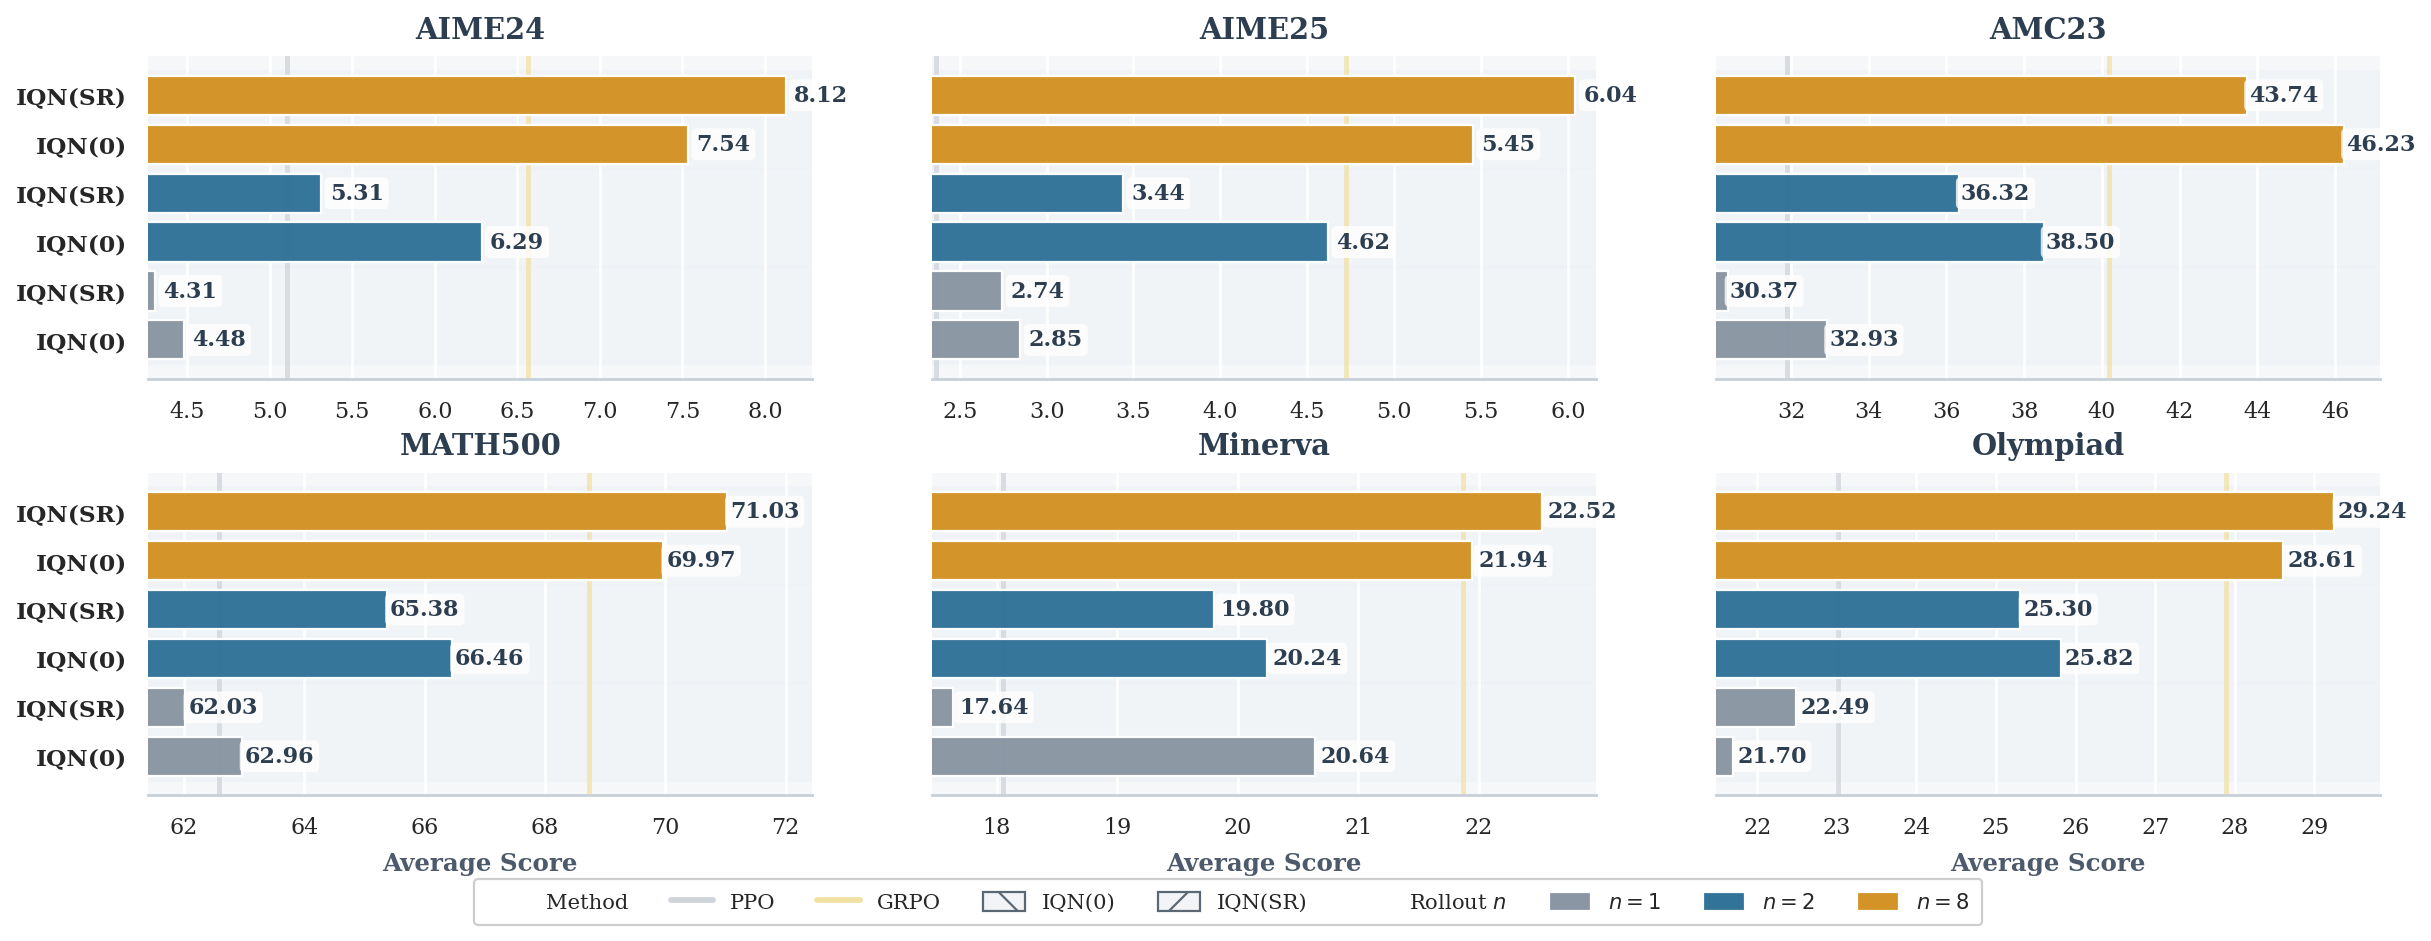

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

def plot_rolloutn_horizontal(
    df,
    *,
    title_main='AIME24',
    title_sub='',
    palette_name='slate_coral',
    show_group_panels=True,
    panel_color='#eef2f6',
    panel_alpha=0.6,
    ax=None,
    show_legend=True,
    tight_layout=True,
):
    """Horizontal bars: color by Rollout n, hatch by Method."""
    method_order = ['PPO', 'GRPO', 'IQN(0)', 'IQN(SR)']
    group_order = ['n=1', 'n=2', 'n=8']

    df = df.copy()
    df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)
    df['Group']  = pd.Categorical(df['Group'],  categories=group_order,  ordered=True)

    # ====== 风格 ======
    sns.set_theme(style='white', font_scale=1.2)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['axes.facecolor'] = '#f6f7f9'
    plt.rcParams['grid.color'] = 'white'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 1.2

    # ====== 配色：Rollout n ======
    palettes = {
        'slate_coral': {
            'n=1': '#C9D2DC',
            'n=2': '#88A2B8',
            'n=8': '#4C6E8A',
        },
        'navy_teal': {
            'n=1': '#8A96A3',
            'n=2': "#327399",
            'n=8': "#D39326",
        },
        'graphite_cyan': {
            'n=1': '#D5DBE0',
            'n=2': '#8CA3B3',
            'n=8': '#2F6F8F',
        },
    }
    palette = palettes.get(palette_name, palettes['slate_coral'])

    # ====== hatch：Method 固定 / \ . ======
    hatch_by_method = {
        'PPO': '',
        'GRPO': '',
        'IQN(0)': '\\',
        'IQN(SR)': '/',
    }

    # PPO/GRPO show as vertical lines
    special_methods = {
        'PPO': '#cfd4da',
        'GRPO': '#f2e1a3',
    }

    # ====== 数据排序 & 画图 ======
    df_lines = df[df['Method'].isin(special_methods.keys())].sort_values(['Group', 'Method']).copy()
    plot_df = df[~df['Method'].isin(special_methods.keys())].sort_values(['Group', 'Method']).copy()
    ypos = np.arange(len(plot_df))

    if ax is None:
        fig, ax = plt.subplots(figsize=(10.6, 5.6), dpi=160)
    else:
        fig = ax.figure

    ax.set_axisbelow(True)
    ax.xaxis.grid(True)

    # 记录每个 group 的 y 范围，用于 panel
    group_spans = {}
    for g in group_order:
        idx = np.where(plot_df['Group'].values == g)[0]
        if len(idx) == 0:
            continue
        group_spans[g] = (int(idx.min()), int(idx.max()))

    if show_group_panels:
        for i, (g, (ys, ye)) in enumerate(group_spans.items()):
            ax.axhspan(
                ys - 0.5, ye + 0.5,
                color=panel_color,
                alpha=panel_alpha if i % 2 == 0 else panel_alpha * 0.85,
                zorder=0,
            )

    # bars: color by group (skip PPO/GRPO bars)
    widths = []
    colors = []
    for g, m, score in zip(plot_df['Group'], plot_df['Method'], plot_df['Score']):
        if str(m) in special_methods:
            widths.append(0)
            colors.append('none')
        else:
            widths.append(score)
            colors.append(palette[g])

    bars = ax.barh(
        y=ypos,
        width=widths,
        color=colors,
        edgecolor='white',
        linewidth=1.0,
        alpha=0.98,
        zorder=2,
    )

    # PPO/GRPO vertical lines
    for m, score in zip(df_lines['Method'], df_lines['Score']):
        if str(m) in special_methods:
            ax.axvline(score, color=special_methods[str(m)], linewidth=2.2, alpha=0.75, zorder=1)

    # value labels
    for i, (score, method) in enumerate(zip(plot_df['Score'], plot_df['Method'])):
        if str(method) in special_methods:
            continue
        ax.text(
            score + 0.05, i,
            f'{score:.2f}',
            va='center', fontsize=10, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='none', alpha=0.8),
            zorder=3,
        )

    ax.set_yticks(ypos)
    ax.set_yticklabels(list(plot_df['Method']), fontsize=10.5, fontweight='bold')

    ax.set_xlabel('Average Score', fontsize=11, labelpad=6, fontweight='bold', color='#4d5a6b')

    ax.set_title(title_main, fontsize=13, pad=8, weight='bold', loc='center', color='#2c3e50')
    if title_sub:
        ax.text(
            0.0, 1.02, title_sub,
            transform=ax.transAxes,
            ha='left', va='bottom',
            fontsize=11, color='#4d5a6b', fontweight='bold'
        )

    # xmin = df['Score'].min() - 0.1
    # xmax = df['Score'].max() + 0.4


    xmin = df['Score'].min() *0.99
    xmax = df['Score'].max() *1.02


    ax.set_xlim(xmin, xmax)
    ax.tick_params(axis='x', labelsize=10)

    # ====== legend：Method (hatch) + Rollout n (color) ======
    method_handles = []
    for m in ['PPO', 'GRPO']:
        if m in df_lines['Method'].unique():
            method_handles.append(
                Line2D([0], [0], color=special_methods[m], linewidth=2.6, label=m)
            )

    for m in method_order:
        if m in plot_df['Method'].unique():
            method_handles.append(
                mpatches.Patch(facecolor='#F2F4F7', edgecolor='#5B6773', linewidth=1.0, hatch=hatch_by_method[m], label=m)
            )

    group_label_map = {
        'n=1': r'$n=1$',
        'n=2': r'$n=2$',
        'n=8': r'$n=8$',
    }

    group_handles = []
    for g in group_order:
        if g in plot_df['Group'].unique():
            group_handles.append(
                mpatches.Patch(facecolor=palette[g], edgecolor='white', label=group_label_map.get(g, g))
            )

    if show_legend:
        # 两段式图例：上 Method（纹理），下 Rollout n（颜色）
        leg1 = ax.legend(
            handles=method_handles,
            title='Method (hatch)',
            frameon=True,
            facecolor='white',
            framealpha=0.95,
            loc='lower right',
            bbox_to_anchor=(1.0, 0.38),
            borderpad=0.6,
            handlelength=2.0,
            handleheight=1.0,
            prop={'size': 9.5, 'weight': 'normal'},
        )
        leg1.get_title().set_fontweight('bold')
        ax.add_artist(leg1)

        leg2 = ax.legend(
            handles=group_handles,
            title='Rollout n (color)',
            frameon=True,
            facecolor='white',
            framealpha=0.95,
            loc='lower right',
            bbox_to_anchor=(1.0, 0.05),
            borderpad=0.6,
            handlelength=2.0,
            handleheight=1.0,
            prop={'size': 9.5, 'weight': 'normal'},
        )
        leg2.get_title().set_fontweight('bold')

    sns.despine(left=True, bottom=False)
    ax.spines['bottom'].set_color('#c8d0d8')
    if tight_layout:
        plt.tight_layout()
    return fig, ax, method_handles, group_handles


# ====== 数据（6个任务） ======
rows = [
    # group, method, AIME24, AIME25, AMC23, MATH500, Minerva, Olympiad
    ('n=1', 'PPO',     5.104, 2.364, 31.903, 62.590, 18.053, 23.012),
    ('n=1', 'IQN(0)',  4.479, 2.847, 32.932, 62.960, 20.638, 21.698),
    ('n=1', 'IQN(SR)', 4.306, 2.743, 30.371, 62.027, 17.639, 22.491),
    ('n=2', 'IQN(0)',  6.285, 4.618, 38.504, 66.458, 20.240, 25.816),
    ('n=2', 'IQN(SR)', 5.313, 3.438, 36.320, 65.377, 19.803, 25.298),
    ('n=8', 'GRPO',    6.563, 4.722, 40.186, 68.725, 21.871, 27.892),
    ('n=8', 'IQN(0)',  7.535, 5.452, 46.233, 69.969, 21.944, 28.611),
    ('n=8', 'IQN(SR)', 8.125, 6.042, 43.737, 71.025, 22.522, 29.241),
]

columns = ['Group', 'Method', 'AIME24', 'AIME25', 'AMC23', 'MATH500', 'Minerva', 'Olympiad']
base_df = pd.DataFrame(rows, columns=columns)

# ====== 2x3 子图 ======
fig, axes = plt.subplots(2, 3, figsize=(18, 6), dpi=160, sharey='row')

palette_name = 'navy_teal'

tasks = ['AIME24', 'AIME25', 'AMC23', 'MATH500', 'Minerva', 'Olympiad']
for i, task in enumerate(tasks):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    df = base_df[['Group', 'Method', task]].rename(columns={task: 'Score'})
    _, _, method_handles, group_handles = plot_rolloutn_horizontal(
        df,
        palette_name=palette_name,
        title_main=task,
        title_sub='',
        ax=ax,
        show_legend=False,
        tight_layout=False,
    )
    if c != 0:
        ax.tick_params(axis='y', labelleft=False, length=0)
    else:
        ax.tick_params(axis='y', labelleft=True)

    if r == 0:
        ax.set_xlabel('')

# ====== 统一图注 ======
spacer = mpatches.Patch(facecolor='none', edgecolor='none', label='Method')
spacer2 = mpatches.Patch(facecolor='none', edgecolor='none', label='Rollout $n$')
legend_handles = [spacer] + method_handles + [spacer2] + group_handles
legend_labels = [h.get_label() for h in legend_handles]

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.036),
    ncol=len(legend_labels),
    frameon=True,
    facecolor='white',
    framealpha=0.95,
    borderpad=0.6,
    handlelength=2.0,
    handleheight=1.0,
    prop={'size': 9.5},
)

fig.subplots_adjust(bottom=0.11, wspace=0.18, hspace=0.29)
plt.show()


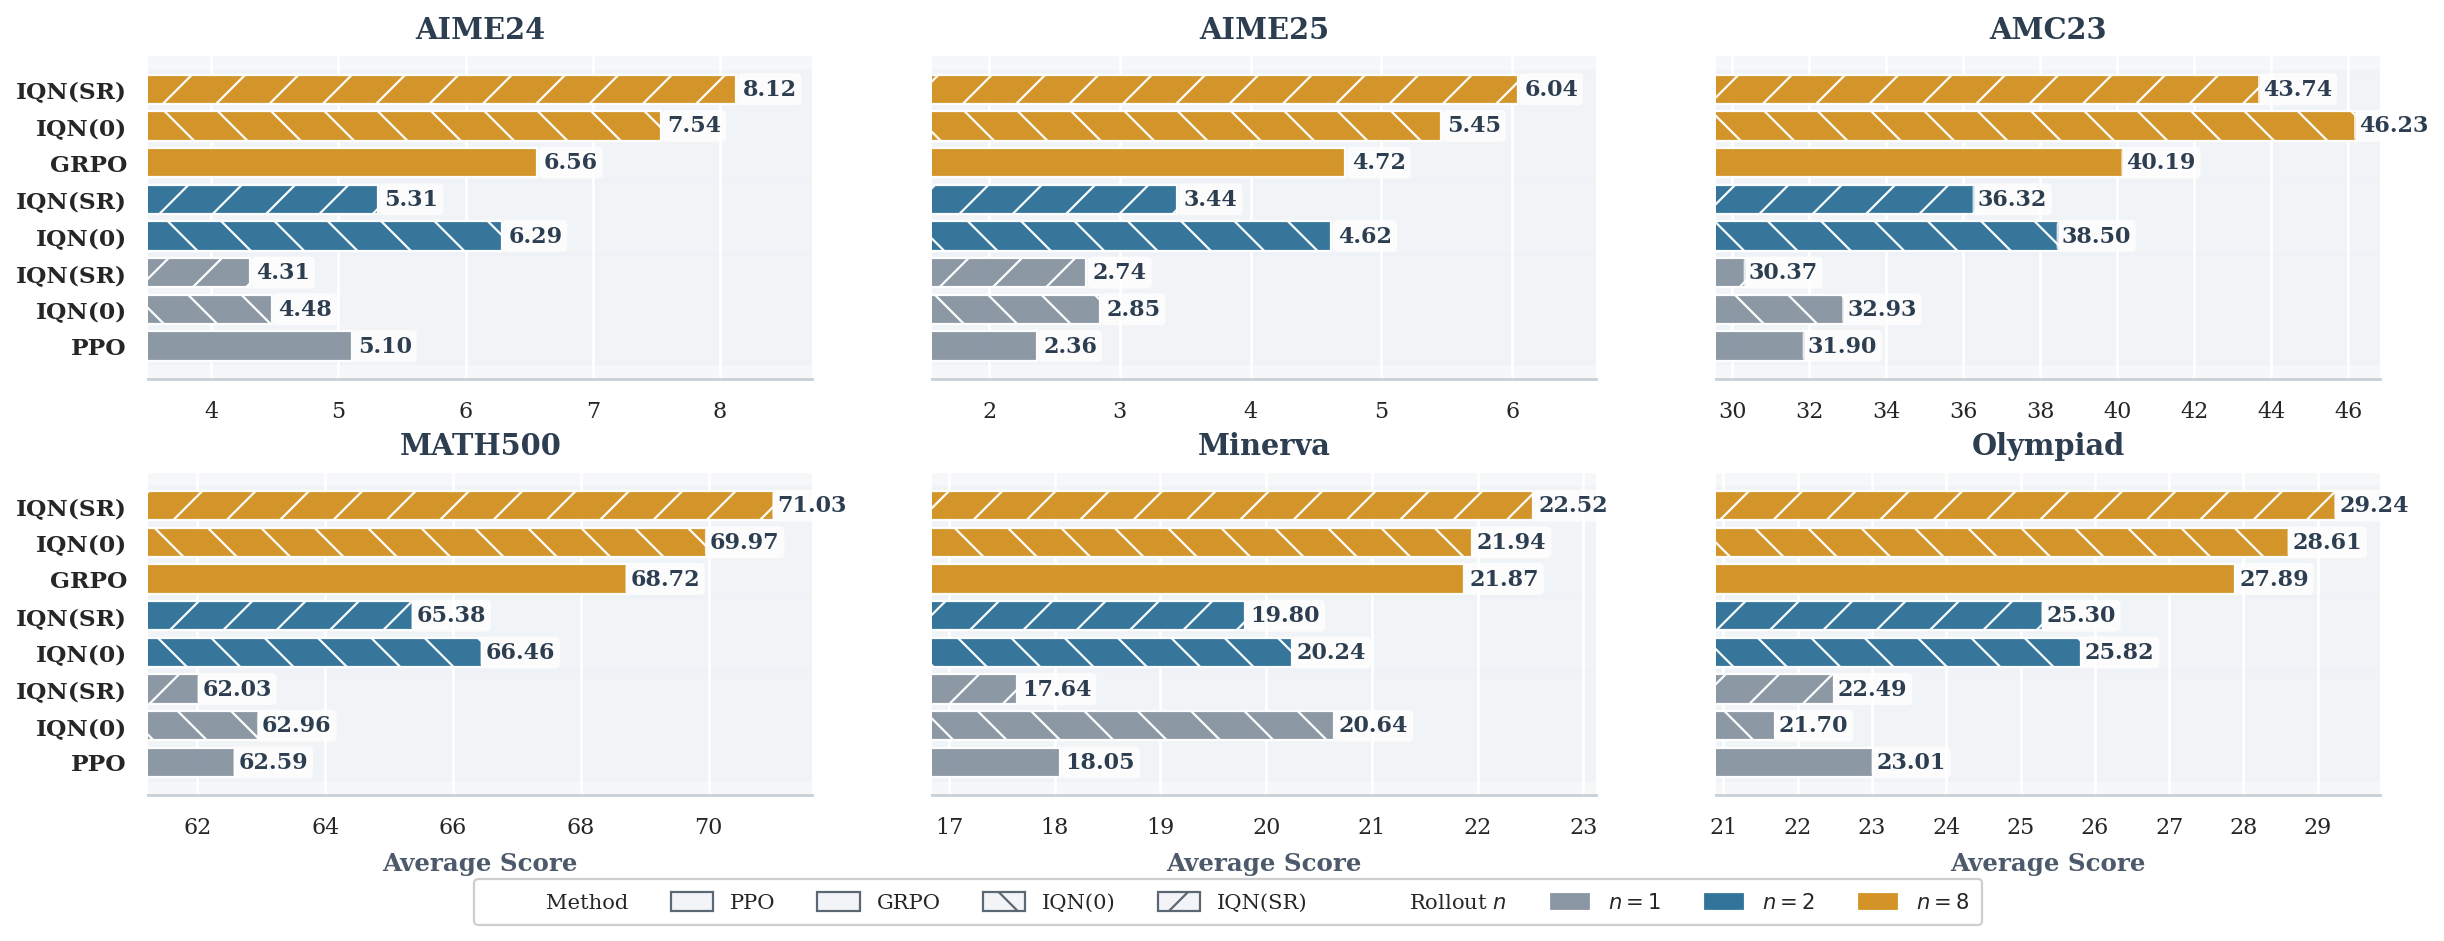

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

def plot_rolloutn_horizontal(
    df,
    *,
    title_main='AIME24',
    title_sub='',
    palette_name='slate_coral',
    show_group_panels=True,
    panel_color='#eef2f6',
    panel_alpha=0.6,
    ax=None,
    show_legend=True,
    tight_layout=True,
):
    """Horizontal bars: color by Rollout n, hatch by Method."""
    method_order = ['PPO', 'GRPO', 'IQN(0)', 'IQN(SR)']
    group_order = ['n=1', 'n=2', 'n=8']

    df = df.copy()
    df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)
    df['Group']  = pd.Categorical(df['Group'],  categories=group_order,  ordered=True)

    # ====== 风格 ======
    sns.set_theme(style='white', font_scale=1.2)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['axes.facecolor'] = '#f6f7f9'
    plt.rcParams['grid.color'] = 'white'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 1.2

    # ====== 配色：Rollout n ======
    palettes = {
        'slate_coral': {
            'n=1': '#C9D2DC',
            'n=2': '#88A2B8',
            'n=8': '#4C6E8A',
        },
        'navy_teal': {
            'n=1': '#8A96A3',
            'n=2': "#327399",
            'n=8': "#D39326",
        },
        'graphite_cyan': {
            'n=1': '#D5DBE0',
            'n=2': '#8CA3B3',
            'n=8': '#2F6F8F',
        },
    }
    palette = palettes.get(palette_name, palettes['slate_coral'])

    # ====== hatch：Method 固定 / \ . ======
    hatch_by_method = {
        'PPO': '',
        'GRPO': '',
        'IQN(0)': '\\',
        'IQN(SR)': '/',
    }

    # ====== 数据排序 & 画图 ======
    plot_df = df.sort_values(['Group', 'Method']).copy()
    ypos = np.arange(len(plot_df))

    if ax is None:
        fig, ax = plt.subplots(figsize=(10.6, 5.6), dpi=160)
    else:
        fig = ax.figure

    ax.set_axisbelow(True)
    ax.xaxis.grid(True)

    # 记录每个 group 的 y 范围，用于 panel
    group_spans = {}
    for g in group_order:
        idx = np.where(plot_df['Group'].values == g)[0]
        if len(idx) == 0:
            continue
        group_spans[g] = (int(idx.min()), int(idx.max()))

    if show_group_panels:
        for i, (g, (ys, ye)) in enumerate(group_spans.items()):
            ax.axhspan(
                ys - 0.5, ye + 0.5,
                color=panel_color,
                alpha=panel_alpha if i % 2 == 0 else panel_alpha * 0.85,
                zorder=0,
            )

    # bars: color by group
    bars = ax.barh(
        y=ypos,
        width=plot_df['Score'],
        color=[palette[g] for g in plot_df['Group']],
        edgecolor='white',
        linewidth=1.0,
        alpha=0.98,
        zorder=2,
    )
    # hatch by method
    for i, m in enumerate(plot_df['Method']):
        bars[i].set_hatch(hatch_by_method.get(str(m), ''))

    # value labels
    for i, score in enumerate(plot_df['Score']):
        ax.text(
            score + 0.05, i,
            f'{score:.2f}',
            va='center', fontsize=10, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='none', alpha=0.8),
            zorder=3,
        )

    ax.set_yticks(ypos)
    ax.set_yticklabels(list(plot_df['Method']), fontsize=10.5, fontweight='bold')

    ax.set_xlabel('Average Score', fontsize=11, labelpad=6, fontweight='bold', color='#4d5a6b')

    ax.set_title(title_main, fontsize=13, pad=8, weight='bold', loc='center', color='#2c3e50')
    if title_sub:
        ax.text(
            0.0, 1.02, title_sub,
            transform=ax.transAxes,
            ha='left', va='bottom',
            fontsize=11, color='#4d5a6b', fontweight='bold'
        )

    xmin = df['Score'].min() - 0.8
    xmax = df['Score'].max() + 0.6
    ax.set_xlim(xmin, xmax)
    ax.tick_params(axis='x', labelsize=10)

    # ====== legend：Method (hatch) + Rollout n (color) ======
    method_handles = []
    for m in method_order:
        if m in plot_df['Method'].unique():
            method_handles.append(
                mpatches.Patch(facecolor='#F2F4F7', edgecolor='#5B6773', linewidth=1.0, hatch=hatch_by_method[m], label=m)
            )

    group_label_map = {
        'n=1': r'$n=1$',
        'n=2': r'$n=2$',
        'n=8': r'$n=8$',
    }

    group_handles = []
    for g in group_order:
        if g in plot_df['Group'].unique():
            group_handles.append(
                mpatches.Patch(facecolor=palette[g], edgecolor='white', label=group_label_map.get(g, g))
            )

    if show_legend:
        # 两段式图例：上 Method（纹理），下 Rollout n（颜色）
        leg1 = ax.legend(
            handles=method_handles,
            title='Method (hatch)',
            frameon=True,
            facecolor='white',
            framealpha=0.95,
            loc='lower right',
            bbox_to_anchor=(1.0, 0.38),
            borderpad=0.6,
            handlelength=2.0,
            handleheight=1.0,
            prop={'size': 9.5, 'weight': 'normal'},
        )
        leg1.get_title().set_fontweight('bold')
        ax.add_artist(leg1)

        leg2 = ax.legend(
            handles=group_handles,
            title='Rollout n (color)',
            frameon=True,
            facecolor='white',
            framealpha=0.95,
            loc='lower right',
            bbox_to_anchor=(1.0, 0.05),
            borderpad=0.6,
            handlelength=2.0,
            handleheight=1.0,
            prop={'size': 9.5, 'weight': 'normal'},
        )
        leg2.get_title().set_fontweight('bold')

    sns.despine(left=True, bottom=False)
    ax.spines['bottom'].set_color('#c8d0d8')
    if tight_layout:
        plt.tight_layout()
    return fig, ax, method_handles, group_handles


# ====== 数据（6个任务） ======
rows = [
    # group, method, AIME24, AIME25, AMC23, MATH500, Minerva, Olympiad
    ('n=1', 'PPO',     5.104, 2.364, 31.903, 62.590, 18.053, 23.012),
    ('n=1', 'IQN(0)',  4.479, 2.847, 32.932, 62.960, 20.638, 21.698),
    ('n=1', 'IQN(SR)', 4.306, 2.743, 30.371, 62.027, 17.639, 22.491),
    ('n=2', 'IQN(0)',  6.285, 4.618, 38.504, 66.458, 20.240, 25.816),
    ('n=2', 'IQN(SR)', 5.313, 3.438, 36.320, 65.377, 19.803, 25.298),
    ('n=8', 'GRPO',    6.563, 4.722, 40.186, 68.725, 21.871, 27.892),
    ('n=8', 'IQN(0)',  7.535, 5.452, 46.233, 69.969, 21.944, 28.611),
    ('n=8', 'IQN(SR)', 8.125, 6.042, 43.737, 71.025, 22.522, 29.241),
]

columns = ['Group', 'Method', 'AIME24', 'AIME25', 'AMC23', 'MATH500', 'Minerva', 'Olympiad']
base_df = pd.DataFrame(rows, columns=columns)

# ====== 2x3 子图 ======
fig, axes = plt.subplots(2, 3, figsize=(18, 6), dpi=160, sharey='row')

palette_name = 'navy_teal'

tasks = ['AIME24', 'AIME25', 'AMC23', 'MATH500', 'Minerva', 'Olympiad']
for i, task in enumerate(tasks):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    df = base_df[['Group', 'Method', task]].rename(columns={task: 'Score'})
    _, _, method_handles, group_handles = plot_rolloutn_horizontal(
        df,
        palette_name=palette_name,
        title_main=task,
        title_sub='',
        ax=ax,
        show_legend=False,
        tight_layout=False,
    )
    if c != 0:
        ax.tick_params(axis='y', labelleft=False, length=0)
    else:
        ax.tick_params(axis='y', labelleft=True)

    if r == 0:
        ax.set_xlabel('')

# ====== 统一图注 ======
spacer = mpatches.Patch(facecolor='none', edgecolor='none', label='Method')
spacer2 = mpatches.Patch(facecolor='none', edgecolor='none', label='Rollout $n$')
legend_handles = [spacer] + method_handles + [spacer2] + group_handles
legend_labels = [h.get_label() for h in legend_handles]

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.036),
    ncol=len(legend_labels),
    frameon=True,
    facecolor='white',
    framealpha=0.95,
    borderpad=0.6,
    handlelength=2.0,
    handleheight=1.0,
    prop={'size': 9.5},
)

fig.subplots_adjust(bottom=0.11, wspace=0.18, hspace=0.29)
plt.show()
